In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

## Comparison of baselines

In [2]:
def plot_scheduler_radar(data, title="Radar Plot"):
    """
    Generate a radar chart for scheduling algorithms from a complex results dict.
    Includes Carbon Emissions as a factor, and flips 'lower-is-better' metrics so
    that higher is always better (outward = better performance).

    Parameters
    ----------
    data : dict
        Dictionary in the form:
        {
            "Algo Name": {
                "Avg Wait": value,
                "Max Wait": value,
                "Avg Response": value,
                "Avg Slowdown": value,
                "System Utilization": value,
                "Carbon Emissions": value,
                ...
            },
            ...
        }
    title : str
        Title for the radar chart.
    """

    # Metrics to plot
    metrics = ["Avg Wait", "Max Wait", "Avg Response", 
               "Avg Slowdown", "System Utilization", "Carbon Emissions"]
    num_vars = len(metrics)

    # Define which metrics should be inverted (lower is better → higher is better)
    invert_metrics = {"Avg Wait", "Max Wait", "Avg Response", 
                      "Avg Slowdown", "Carbon Emissions"}

    # Collect raw values
    all_values = {m: [float(algo[m]) for algo in data.values()] for m in metrics}
    mins = {m: min(v) for m,v in all_values.items()}
    maxs = {m: max(v) for m,v in all_values.items()}

    # Angles for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for algo, values in data.items():
        stats = []
        for m in metrics:
            raw_val = float(values[m])

            # normalize to [0,1]
            if maxs[m] > mins[m]:
                norm_val = (raw_val - mins[m]) / (maxs[m] - mins[m])
            else:
                norm_val = 0.5  # if identical across algos

            # invert if lower is better
            if m in invert_metrics:
                norm_val = 1 - norm_val

            stats.append(norm_val)

        stats += stats[:1]  # close loop
        ax.plot(angles, stats, label=algo)
        ax.fill(angles, stats, alpha=0.1)

    # Set axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=10)

    plt.title(title, size=14, y=1.1)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()


In [3]:
data = {'10-percentile Baseline': {'Avg Wait': np.float64(122535.884585211), 'Max Wait': np.float64(122535.884585211), 'Avg Response': np.float64(125674.48751163088), 'Avg Slowdown': np.float64(14798.97326313907), 'Carbon Emissions': np.float64(39400634.574480005), 'Weighted Carbon Emissions': np.float64(-39400634.574480005), 'System Utilization': np.float64(0.3103515146727806), 'Action Analysis': {'Total Actions': 231733, 'Schedule Action Percentage': 23.652651974470622, 'Fixed Delay Percentage': 50.11327691783216, 'Wait Delay Percentage': 26.234071107697222, 'Fixed Delays': {'300s': 116129}, 'Wait for Jobs': {'1 jobs': 60793}}}, '25-percentile Baseline': {'Avg Wait': np.float64(40473.974585393444), 'Max Wait': np.float64(40473.974585393444), 'Avg Response': np.float64(43612.577511813324), 'Avg Slowdown': np.float64(4765.192723789244), 'Carbon Emissions': np.float64(39739681.57938555), 'Weighted Carbon Emissions': np.float64(-39739681.57938555), 'System Utilization': np.float64(0.3148453798868719), 'Action Analysis': {'Total Actions': 223360, 'Schedule Action Percentage': 24.539308739255013, 'Fixed Delay Percentage': 45.311604584527224, 'Wait Delay Percentage': 30.149086676217763, 'Fixed Delays': {'300s': 101208}, 'Wait for Jobs': {'1 jobs': 67341}}}, '50-percentile Baseline': {'Avg Wait': np.float64(14724.930232982431), 'Max Wait': np.float64(14724.930232982431), 'Avg Response': np.float64(17863.53315940231), 'Avg Slowdown': np.float64(1744.419494702105), 'Carbon Emissions': np.float64(40412871.13513241), 'Weighted Carbon Emissions': np.float64(-40412871.13513241), 'System Utilization': np.float64(0.31561697687395124), 'Action Analysis': {'Total Actions': 211667, 'Schedule Action Percentage': 25.89491985051992, 'Fixed Delay Percentage': 37.42813003444089, 'Wait Delay Percentage': 36.67695011503918, 'Fixed Delays': {'300s': 79223}, 'Wait for Jobs': {'1 jobs': 77633}}}, 'FCFS Baseline': {'Avg Wait': np.float64(652.7688237762493), 'Max Wait': np.float64(652.7688237762493), 'Avg Response': np.float64(3791.3717501961287), 'Avg Slowdown': np.float64(40.25529469855725), 'Carbon Emissions': np.float64(40828055.65787667), 'Weighted Carbon Emissions': np.float64(-40828055.65787667), 'System Utilization': np.float64(0.3161761429547774), 'Action Analysis': {'Total Actions': 184926, 'Schedule Action Percentage': 29.639423336902325, 'Fixed Delay Percentage': 12.17243654218444, 'Wait Delay Percentage': 58.18814012091323, 'Fixed Delays': {'300s': 22510}, 'Wait for Jobs': {'1 jobs': 107605}}}}


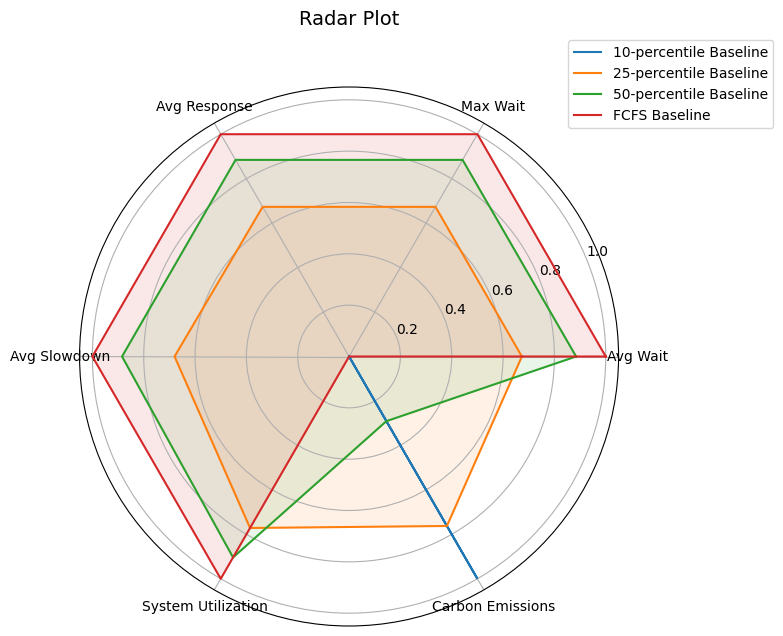

In [4]:
plot_scheduler_radar(data)

## Workload  statistics

In [5]:
def create_job_df(path):
    rows = []
    with open(path) as fp:
        for line in fp:
            if line.startswith(";"):
                continue
            line = line.strip()
            s_array = re.split(r"\s+", line)
            
            # Append to standard Python lists
            submit_time = int(s_array[1])
            req_processors = int(s_array[4])
            req_run_time = int(s_array[3])

            rows.append({"submit_time": submit_time, "requested_processors": req_processors, "requested_runtime": req_run_time})

    return pd.DataFrame(rows);

def plot_workload_patterns(
    df: pd.DataFrame,
    origin="2021-01-01",
    time_unit="s",                 # "s" if submit_time is in seconds; use "ms" if milliseconds, etc.
    runtime_bins_hours=None,       # custom edges in HOURS; leave None to use fine short bins below
    runtime_clip_q=None            # e.g., 0.995 to clip long tail before binning; or None
):
    need = {"submit_time", "requested_runtime", "requested_processors"}
    miss = need - set(df.columns)
    if miss:
        raise ValueError(f"Missing columns: {sorted(miss)}")

    df = df.copy()
    df["submit_time"] = pd.to_numeric(df["submit_time"], errors="coerce")
    df["requested_runtime"] = pd.to_numeric(df["requested_runtime"], errors="coerce")
    df["requested_processors"] = pd.to_numeric(df["requested_processors"], errors="coerce")
    df = df.dropna(subset=["submit_time"])
    df = df[df["submit_time"] >= 0]

    # Build timestamps from submit_time
    t0 = pd.to_datetime(origin)
    df["timestamp"] = t0 + pd.to_timedelta(df["submit_time"], unit=time_unit)
    df["hour"] = df["timestamp"].dt.hour

    # ---------- Weekly job submissions (avg per weekday) ----------
    per_day = df.set_index("timestamp").resample("D").size().rename("count")
    weekly_avg = (
        per_day.groupby(per_day.index.weekday).mean().reindex(range(7), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], weekly_avg.values)
    plt.title("Weekly job submission pattern")
    plt.xlabel("Day of week"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Monthly job submissions (avg per day, Jan..Dec across all years) ----------
    # Use resampled daily series so months without submissions still contribute 0 days.
    monthly_avg_per_day = (
        per_day.groupby(per_day.index.month)   # 1..12 across all years
        .mean()
        .reindex(range(1,13), fill_value=0.0)
    )
    plt.figure()
    plt.bar(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            monthly_avg_per_day.values)
    plt.title("Monthly job submission pattern (average per day)")
    plt.xlabel("Month"); plt.ylabel("Average submissions per day")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Hour-of-day submission pattern (percentage) ----------
    hour_pct = (
        df["hour"].value_counts(normalize=True)
        .reindex(range(24), fill_value=0.0)
        .sort_index() * 100.0
    )
    plt.figure()
    plt.bar(range(24), hour_pct.values)
    plt.title("Hourly job submission pattern")
    plt.xlabel("Hour of day"); plt.ylabel("Percentage of submissions")
    plt.xticks(range(24))
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Job size distribution (processors) ----------
    sizes = df["requested_processors"].dropna()
    sizes = sizes[sizes > 0]
    size_bins = [1, 4, 8, 32, 128, 256, np.inf]
    size_labels = ["1-4", "4-8", "8-32", "32-128", "128-256", "256+"]
    cat = pd.cut(sizes, size_bins, right=False, include_lowest=True, labels=size_labels)
    dist_pct = (cat.value_counts().sort_index() / len(sizes)) * 100.0
    plt.figure()
    plt.bar(dist_pct.index.astype(str), dist_pct.values)
    plt.title("Job size distribution (processors)")
    plt.xlabel("Job size bins"); plt.ylabel("Percentage")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

    # ---------- Distribution of requested runtimes (hours) — fine short bins ----------
    rt_h = (df["requested_runtime"].dropna() / 3600.0)
    rt_h = rt_h[rt_h > 0]
    if len(rt_h) == 0:
        plt.figure(); plt.title("Distribution of requested runtimes (hours)")
        plt.text(0.5, 0.5, "No positive runtimes", ha="center"); plt.axis("off"); plt.show()
        return

    if runtime_clip_q:
        rt_h = rt_h.clip(upper=float(rt_h.quantile(runtime_clip_q)))

    # Default: extra-fine bins at short end (minutes), then hour bins
    if runtime_bins_hours is None:
        mins = np.array([0,1, 2, 5, 10, 15, 20, 30, 45, 60]) / 60.0
        hrs  = np.array([2, 4, 8, 12, 24, 48, np.inf], dtype=float)
        runtime_bins_hours = np.concatenate([mins, hrs])

    counts, edges = np.histogram(rt_h.values, bins=runtime_bins_hours)
    pct = counts / counts.sum() * 100.0

    def fmt_h(x):
        return f"{x:.0f}h" if x >= 1 else f"{int(round(x*60))}m"

    labels = []
    for i in range(len(edges)-1):
        lo, hi = edges[i], edges[i+1]
        if np.isinf(hi):
            labels.append(f"{fmt_h(lo)}+")
        else:
            labels.append(f"{fmt_h(lo)}–{fmt_h(hi)}")

    plt.figure()
    plt.bar(labels, pct)
    plt.title("Distribution of requested runtimes (hours)")
    plt.xlabel("Requested runtime bins"); plt.ylabel("Percentage of jobs")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

#### COmparison of different traces

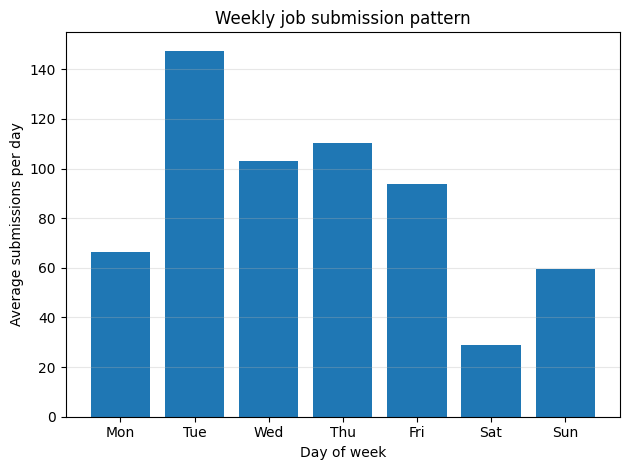

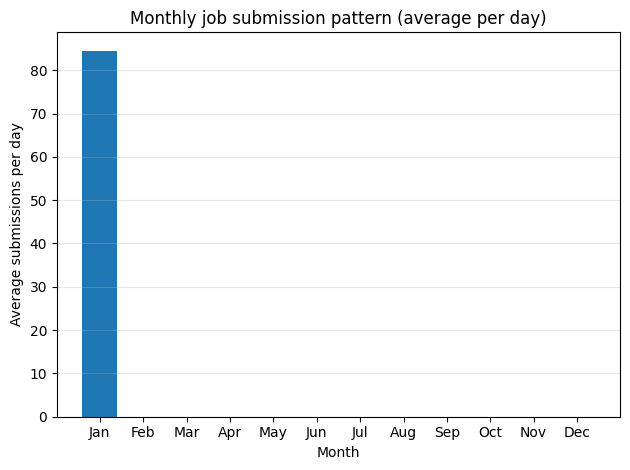

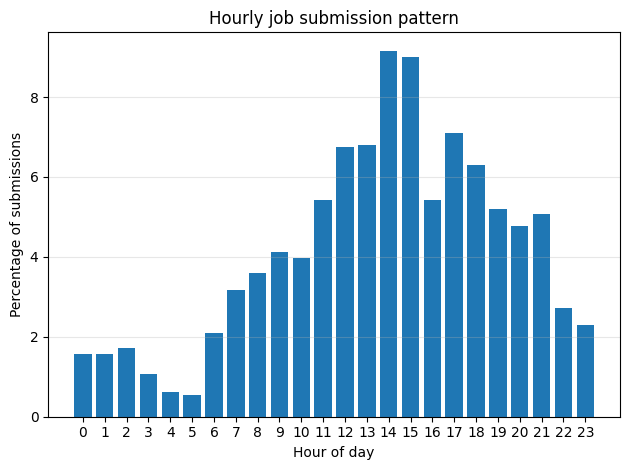

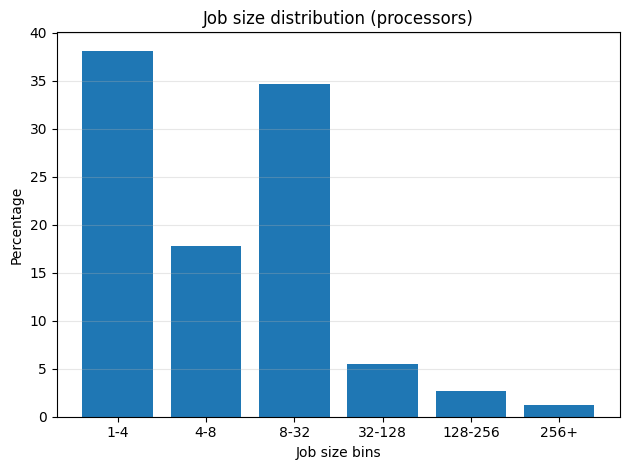

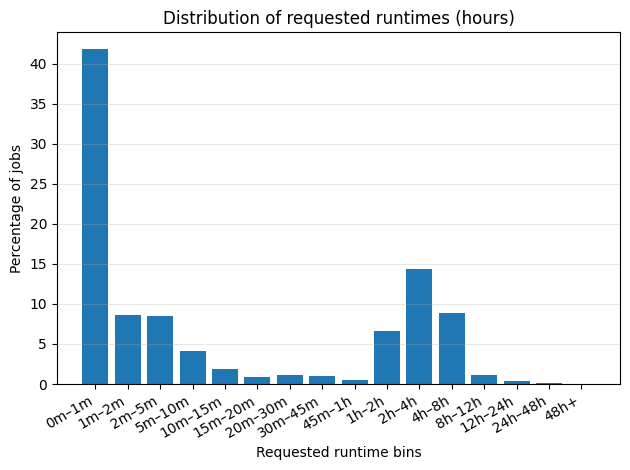

4551.730182926829
4522.246946564886


In [36]:
## Non convergent dataset:
WORKLOAD_PATH_BAD = "scripts/workload_1_31.swf" 
df_bad = create_job_df(path=WORKLOAD_PATH_BAD)

plot_workload_patterns(df_bad)
print(df['requested_runtime'].mean())
print(df_bad["requested_runtime"].mean())

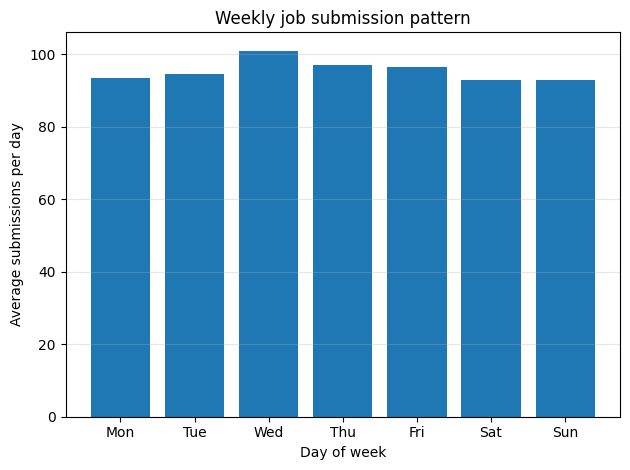

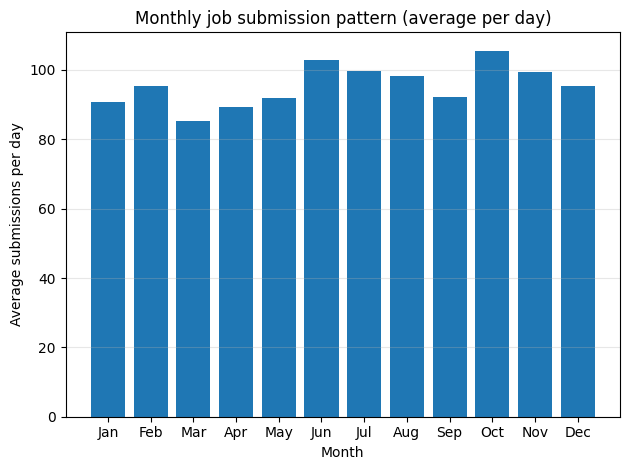

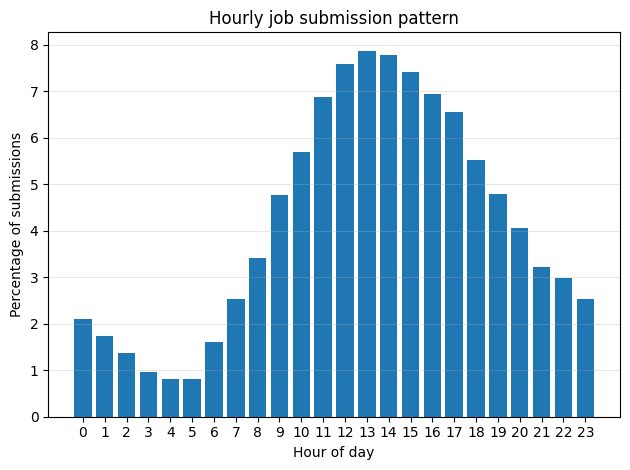

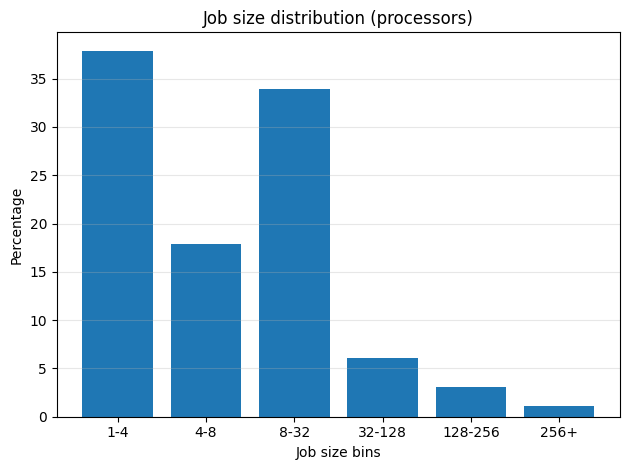

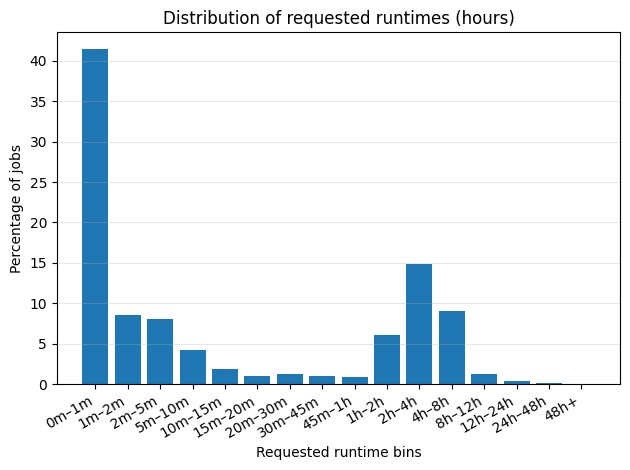

4551.730182926829
4538.300109878758


In [37]:
## Non convergent dataset:
WORKLOAD_PATH_BAD = "scripts/workload_36_31.swf" 
df_bad = create_job_df(path=WORKLOAD_PATH_BAD)

plot_workload_patterns(df_bad)
print(df['requested_runtime'].mean())
print(df_bad["requested_runtime"].mean())

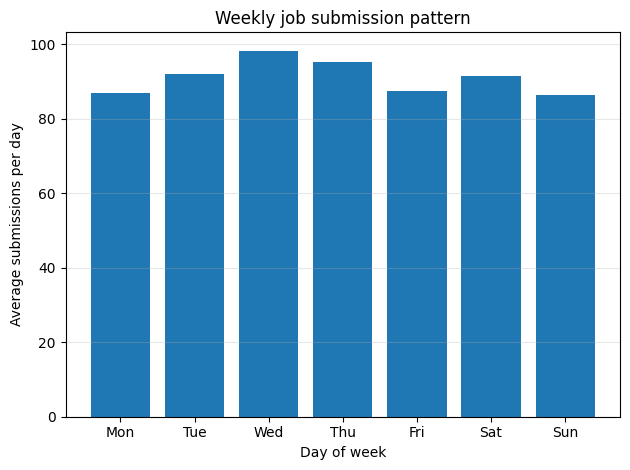

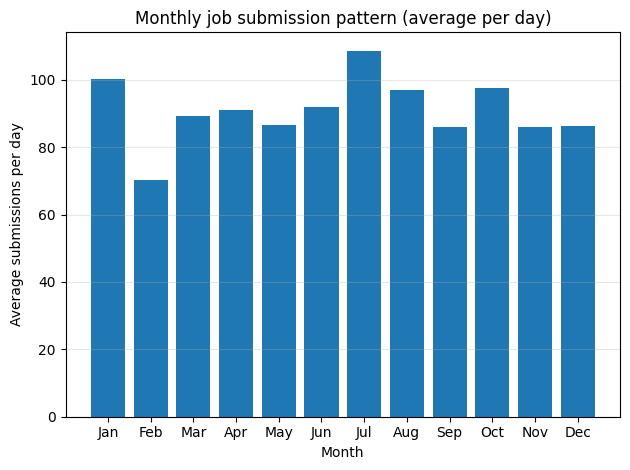

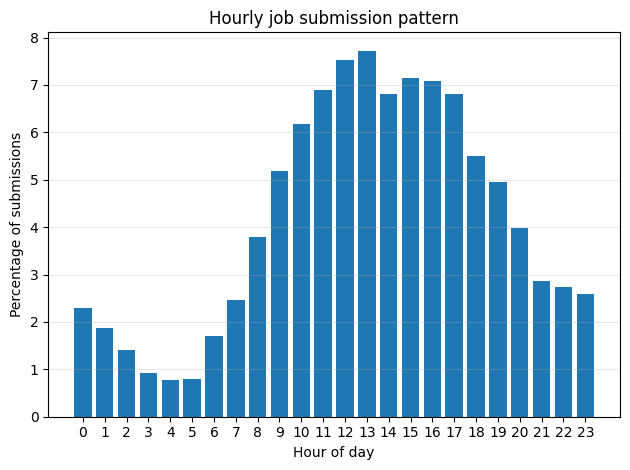

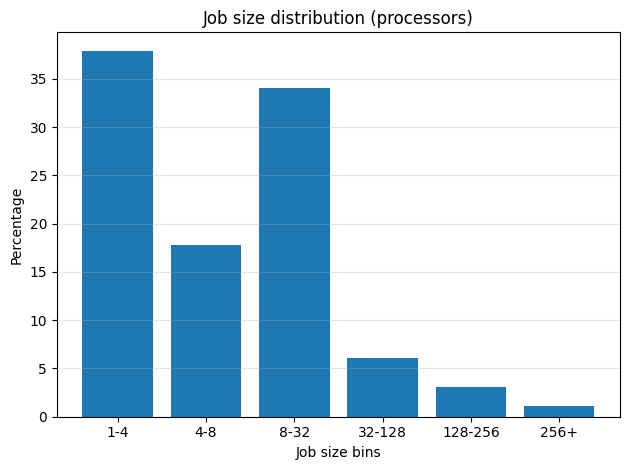

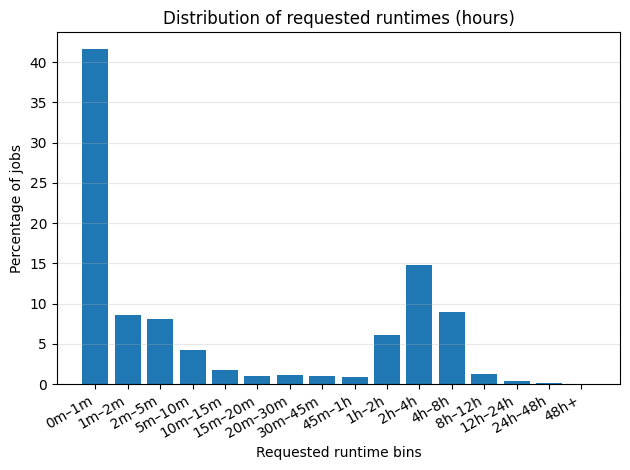

Year 0: n=33260, mean requested_runtime=4519.98


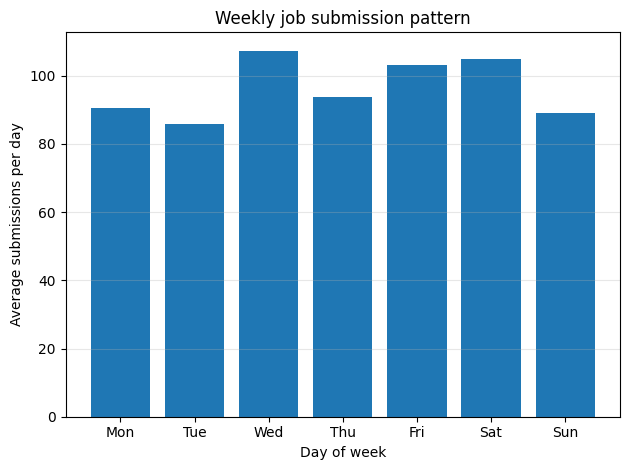

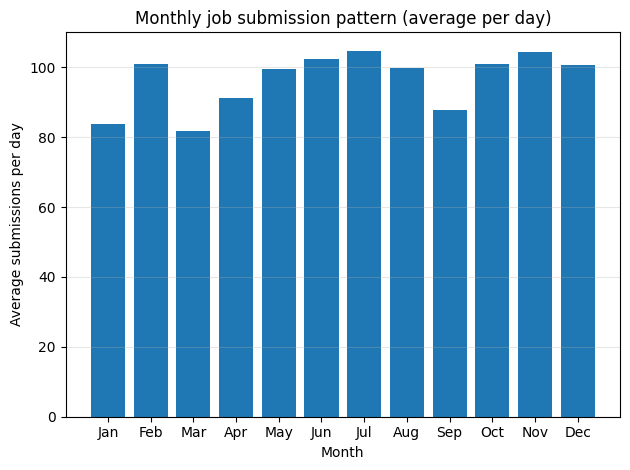

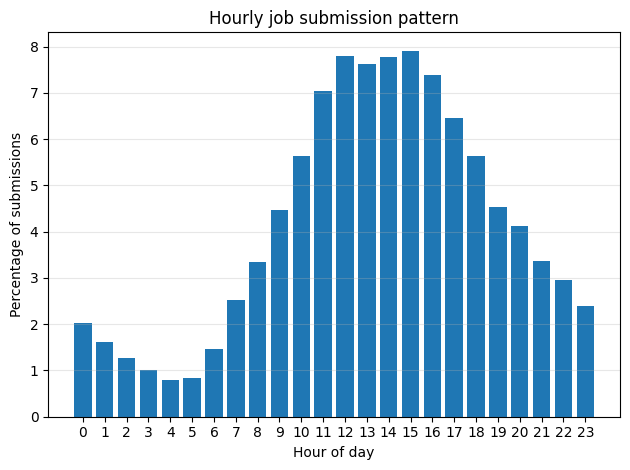

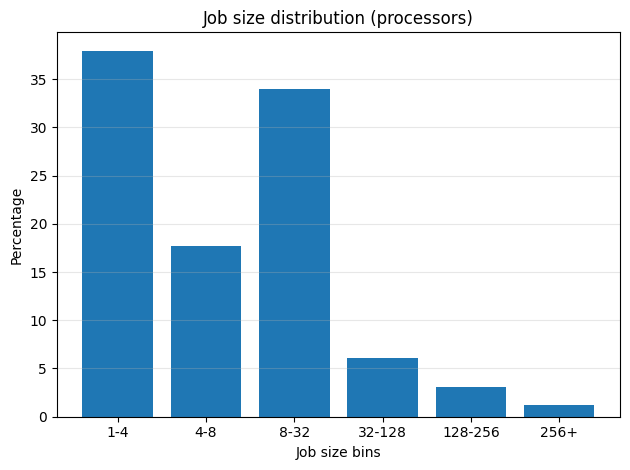

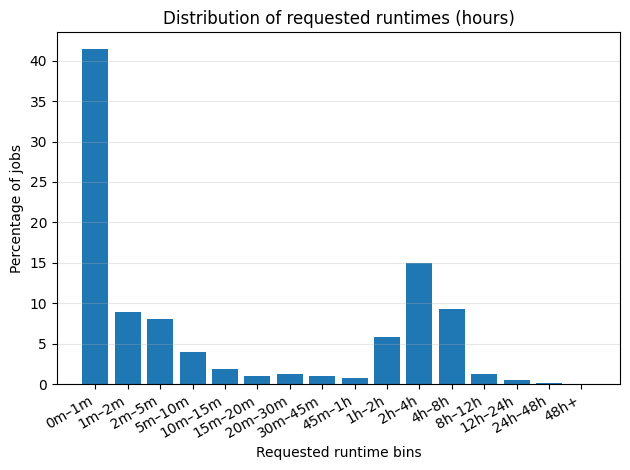

Year 1: n=35187, mean requested_runtime=4583.51


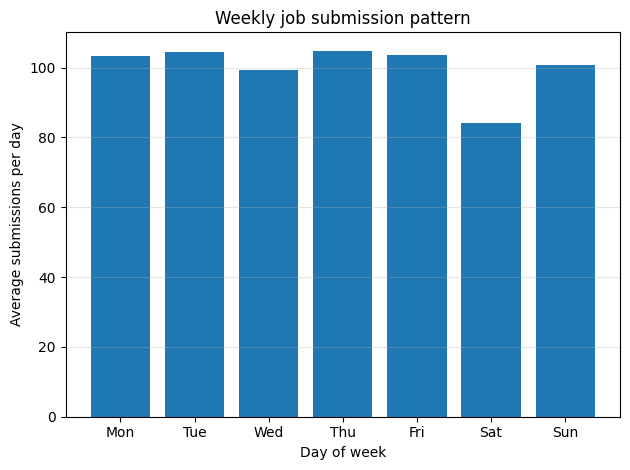

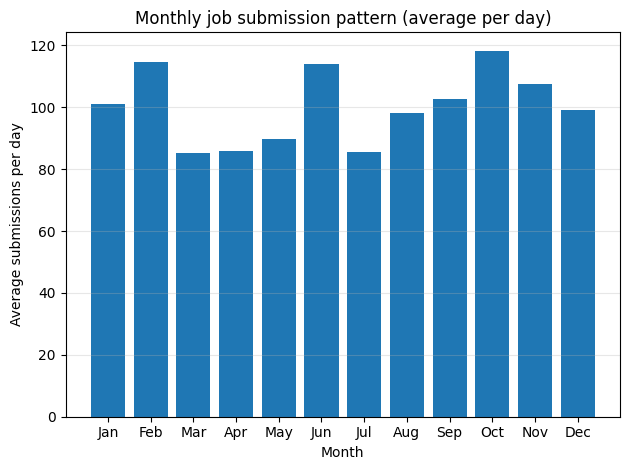

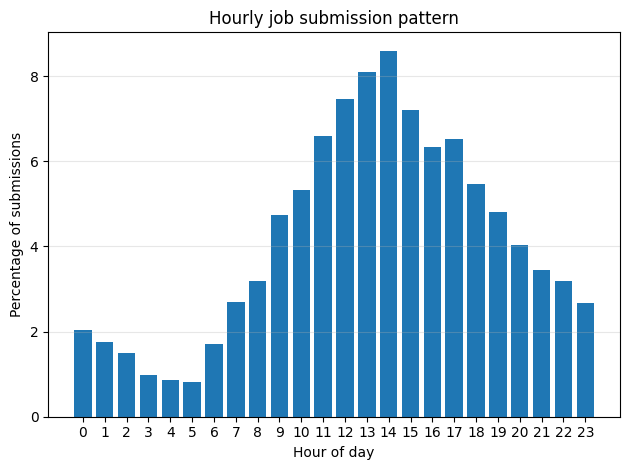

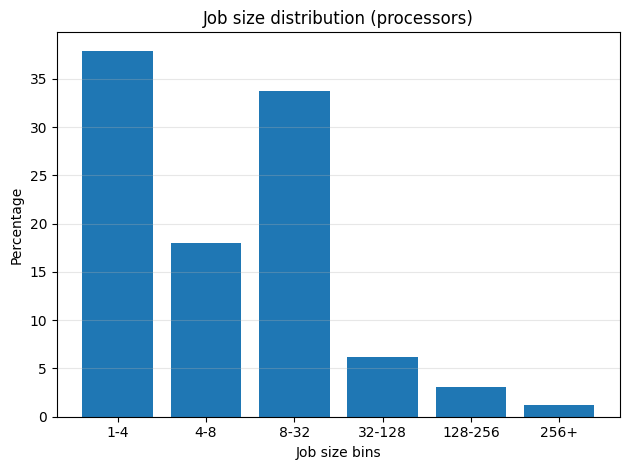

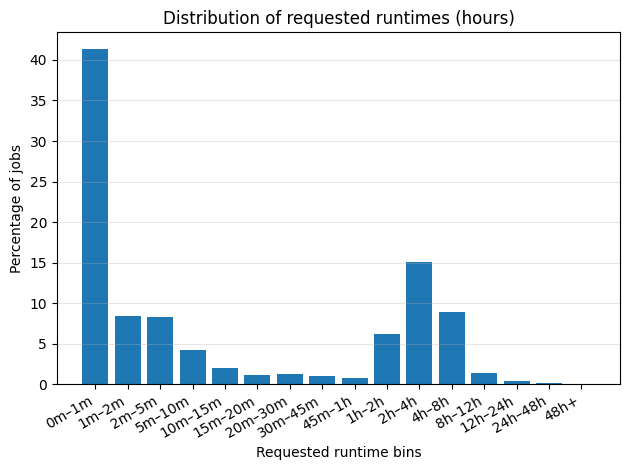

Year 2: n=36506, mean requested_runtime=4508.05


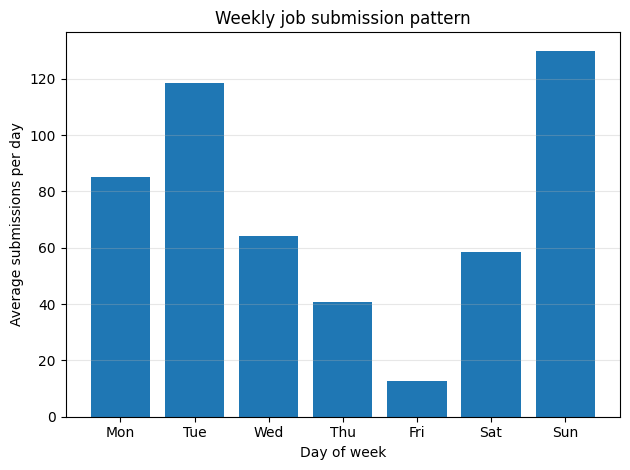

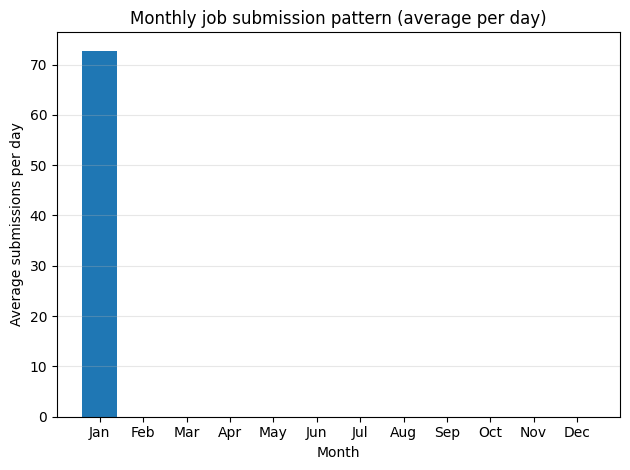

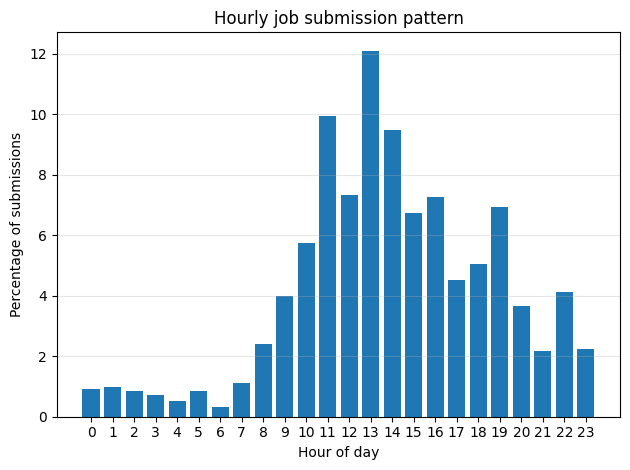

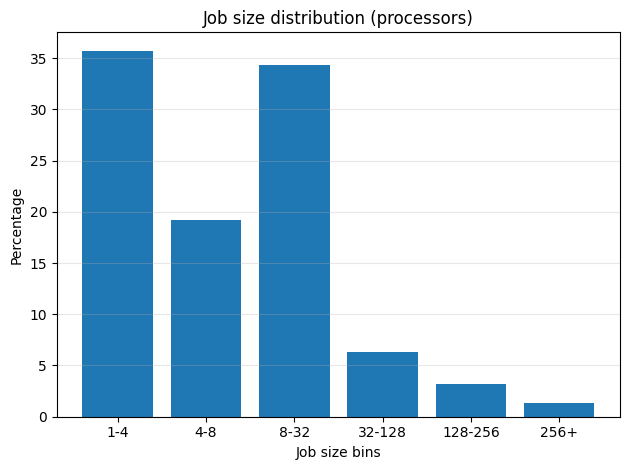

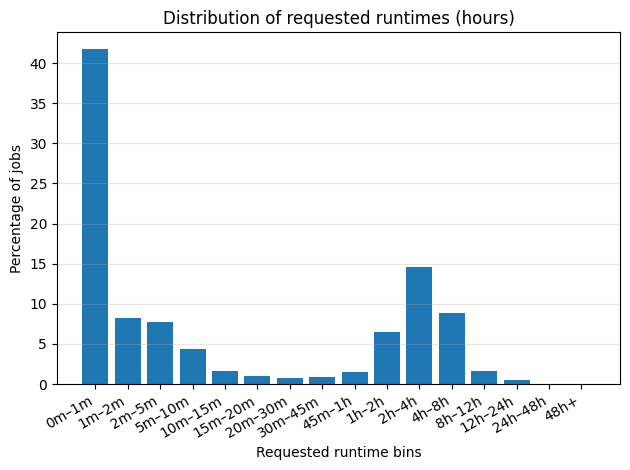

Year 3: n=1528, mean requested_runtime=4618.88


In [38]:
# Non convergent dataset:
WORKLOAD_PATH_BAD = "scripts/workload_36_31.swf"
df_bad = create_job_df(path=WORKLOAD_PATH_BAD)

YEAR = 365 * 24 * 3600  # seconds in a year

for i in range(4):
    lo = i * YEAR
    hi = (i + 1) * YEAR

    # Filter rows whose submit_time is in [lo, hi)
    df_slice = df_bad.loc[(df_bad['submit_time'] >= lo) & (df_bad['submit_time'] < hi)]
    # alternatively:
    # df_slice = df_bad[df_bad['submit_time'].between(lo, hi, inclusive='left')]

    plot_workload_patterns(df_slice)

    # Print stats for the slice, not the whole frame
    mean_req_rt = df_slice['requested_runtime'].mean()
    print(f"Year {i}: n={len(df_slice)}, mean requested_runtime={mean_req_rt:.2f}")


## Carbon intensity statistics

In [ ]:

def read_carbon_csv(path: str) -> pd.DataFrame:
    """
    Reads the CSV and returns a dataframe with columns:
    - timestamp (UTC-aware pandas datetime)
    - value (float)
    """
    # Read first, letting pandas infer headers
    df = pd.read_csv(path, parse_dates=[0])
    # Strip any funny whitespace in headers
    df.columns = [c.strip() for c in df.columns]

    # Robust renaming to standard names
    ts_col = df.columns[0]
    # Try to find the value column by common names
    candidate_value_cols = [c for c in df.columns[1:] if c.strip().lower() in ("value", "carbon intensity", "carbon_intensity", "intensity")]
    value_col = candidate_value_cols[0] if candidate_value_cols else df.columns[1]

    df = df.rename(columns={ts_col: "timestamp", value_col: "value"})

    # Ensure datetime is timezone-aware UTC (source column is UTC)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    # Drop bad rows
    df = df.dropna(subset=["timestamp", "value"]).sort_values("timestamp").reset_index(drop=True)
    return df


def plot_profile_with_std(x, mean_series, std_series, x_tick_labels, x_label, y_label, outfile):
    """
    Plots mean line with a grey ±1 std band. No title.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    mean_vals = np.asarray(mean_series.values, dtype=float)
    std_vals = np.asarray(std_series.fillna(0).values, dtype=float)
    lower = mean_vals - std_vals
    upper = mean_vals + std_vals

    # Mask NaNs so plotting works even if some bins have no data
    x = np.asarray(x)
    valid = ~np.isnan(mean_vals)

    ax.plot(x[valid], mean_vals[valid], linewidth=2, label="Mean", color="black")
    ax.fill_between(x[valid], lower[valid], upper[valid], alpha=0.25, label="±1 SD", color="gray")

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, linestyle="--", alpha=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels, rotation=0)
    ax.legend(loc="best")

    fig.tight_layout()
    fig.savefig(outfile, dpi=150)
    plt.close(fig)

path = "data/DK-DK2_minutely_carbon_intensity_improved.csv"
df = read_carbon_csv(path)

# DAILY PROFILE (by hour 0..23)
by_hour = (
    df.groupby(df["timestamp"].dt.hour)["value"]
    .agg(mean="mean", std="std")
    .reindex(range(24))
)
hours = np.arange(24)
hour_labels = [f"{h:02d}" for h in hours]
plot_profile_with_std(
    x=hours,
    mean_series=by_hour["mean"],
    std_series=by_hour["std"],
    x_tick_labels=hour_labels,
    x_label="Hour of Day (00–23, UTC)",
    y_label="Carbon Intensity",
    outfile="daily_profile.png",
)

# WEEKLY PROFILE (by weekday Mon..Sun)
# Pandas: Monday=0 ... Sunday=6
weekday_order = list(range(7))
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday = (
    df.groupby(df["timestamp"].dt.dayofweek)["value"]
    .agg(mean="mean", std="std")
    .reindex(weekday_order)
)
plot_profile_with_std(
    x=weekday_order,
    mean_series=by_weekday["mean"],
    std_series=by_weekday["std"],
    x_tick_labels=weekday_names,
    x_label="Weekday",
    y_label="Carbon Intensity",
    outfile="weekly_profile.png",
)

# MONTHLY PROFILE (by month Jan..Dec; month-of-year across all years)
month_order = list(range(1, 13))
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
by_month = (
    df.groupby(df["timestamp"].dt.month)["value"]
        .agg(mean="mean", std="std")
        .reindex(month_order)
)
plot_profile_with_std(
    x=month_order,
    mean_series=by_month["mean"],
    std_series=by_month["std"],
    x_tick_labels=month_names,
    x_label="Month",
    y_label="Carbon intensity",
    outfile="monthly_profile.png",
)

# YEARLY PROFILE (by calendar year)
by_year = df.groupby(df["timestamp"].dt.year)["value"].agg(mean="mean", std="std").sort_index()
years = by_year.index.to_numpy()
year_labels = [str(y) for y in years]
plot_profile_with_std(
    x=years,
    mean_series=by_year["mean"],
    std_series=by_year["std"],
    x_tick_labels=year_labels,
    x_label="Year",
    y_label="Carbon Intensity",
    outfile="yearly_profile.png",
)

print("Saved: daily_profile.png, weekly_profile.png, yearly_profile.png")

Saved: daily_profile.png, weekly_profile.png, yearly_profile.png
